In [1]:
#Import Libraries here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import os
import sys
pio.renderers.default = "notebook_connected"

In [2]:
current_dir = os.path.abspath('')
project_root = os.path.abspath(os.path.join(current_dir, '../../'))

if project_root not in sys.path:
    sys.path.append(project_root)

os.chdir(project_root)

print(f"Working directory set to: {os.getcwd()}")

Working directory set to: D:\users\kamen.dimitrov\desktop\softuni\math_concepts_for_developers\08_final_project


In [3]:
#Import project modules here

import importlib
from src.portfolio_simulation_utils import portfolio_simulation as p_sim
from src.data_pipeline_utils import data_fetching_handling as data_pipe
importlib.reload(p_sim)
importlib.reload(data_pipe)

<module 'src.data_pipeline_utils.data_fetching_handling' from 'D:\\users\\kamen.dimitrov\\desktop\\softuni\\math_concepts_for_developers\\08_final_project\\src\\data_pipeline_utils\\data_fetching_handling.py'>

### Let us first choose our stocks and extract the necessary data utilizing the yfinance librabry in Python ###

In [4]:
tickers = ['AAPL', 'NVDA', 'MSFT', 'JNJ', 'BAC', 'VZ', 'WMT', 'UPS', 'PFE', 'JPM']

for ticker in tickers:
    data = data_pipe.save_10_year_single_stock_data_to_csv(ticker)
    return_data = data_pipe.create_returns_and_save(data, ticker)

### Let us randomly check if we have what we need ###

In [5]:
MSFT_data = data_pipe.fetch_raw_data('MSFT')
return_data_PFE = data_pipe.fetch_returns_data('PFE')

print(return_data_PFE)

                Close       High        Low       Open    Volume  \
Date                                                               
2016-02-26  18.512146  18.922440  18.383548  18.848953  45244004   
2016-02-29  18.169218  18.481531  18.107981  18.426417  37091841   
2016-03-01  18.395792  18.426410  18.138593  18.242698  33114256   
2016-03-02  18.359055  18.469283  18.218207  18.438663  36139763   
2016-03-03  18.303938  18.371298  18.114100  18.297813  38881955   
...               ...        ...        ...        ...       ...   
2026-02-19  26.860001  27.400000  26.580000  27.370001  40316800   
2026-02-20  26.650000  26.780001  26.360001  26.709999  44786900   
2026-02-23  27.059999  27.110001  26.500000  26.559999  34166100   
2026-02-24  27.139999  27.420000  27.080000  27.139999  34670900   
2026-02-25  27.094999  27.290001  27.040001  27.055000   2257560   

            daily_return  log_return  daily_return_pct  log_return_pct  
Date                                      

In [6]:
def create_candlestick_graph(ticker):
    data = data_pipe.fetch_raw_data(ticker)

    
    fig = go.Figure(
        data=[
            go.Candlestick(
                x=data.index,
                open=data["Open"],
                high=data["High"],
                low=data["Low"],
                close=data["Close"],
                name=f"{ticker}"
            )
        ]
    )
    
    fig.update_layout(
        title=F"{ticker} Daily Candlestick",
        xaxis_title="Date",
        yaxis_title="Price",
        xaxis_rangeslider_visible=False
    )
    
    fig.show()

def create_histogram_distribution_daily_log_returns(ticker):
    data = data_pipe.fetch_returns_data(ticker)
    
    plt.figure(figsize=(10,6))
    plt.hist(data["log_return_pct"], bins=100)
    plt.title(F"Distribution of {ticker} Daily Log Returns")
    plt.xlabel("Log Return")
    plt.ylabel("Frequency")
    plt.show()


def create_correlation_heatmap(corr_matrix):
    plt.figure(figsize=(8,6))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        linewidths=0.5
    )

    plt.title("Correlation Matrix Heatmap")
    plt.show()

create_candlestick_graph('MSFT')

Mean log return in observation period: 0.0008577408649093585,
Variance of log returns in observation period: 0.0002867062275220041,
Standard deviation of log returns in observation period: 0.016932401705664915


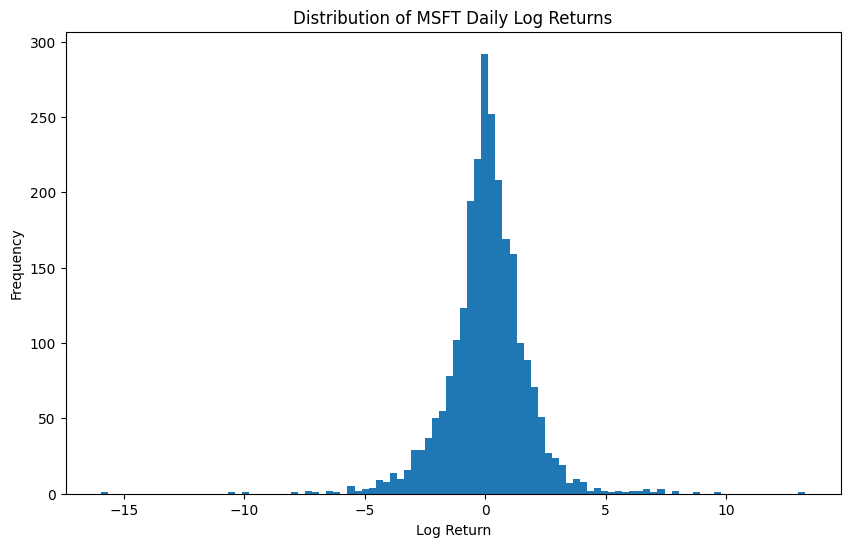

In [7]:
MSFT_return_data = data_pipe.fetch_returns_data('MSFT')
mean = MSFT_return_data["log_return"].mean()
variance = MSFT_return_data["log_return"].var()
st_dev = MSFT_return_data["log_return"].std()
print(f"Mean log return in observation period: {mean},\n"
      f"Variance of log returns in observation period: {variance},\n"
      f"Standard deviation of log returns in observation period: {st_dev}")


create_histogram_distribution_daily_log_returns('MSFT')

In [8]:
MSFT_return_data["log_return"].describe()

count    2514.000000
mean        0.000858
std         0.016932
min        -0.159453
25%        -0.006645
50%         0.001038
75%         0.009596
max         0.132929
Name: log_return, dtype: float64

### Covariance Matrix of Stock Returns ###

$$ X =
\begin{bmatrix}
r_{1,1} & r_{2,1} \\
r_{1,2} & r_{2,2} \\
\vdots  & \vdots  \\
r_{1,n} & r_{2,n}
\end{bmatrix} $$


$$ \Sigma = \frac{1}{n-1}(X - \bar{X})^\top (X - \bar{X}) $$

In [9]:
returns_df =  data_pipe.build_returns_df(tickers)

print(returns_df)

cov_matrix = returns_df.cov()
print(cov_matrix)

eigenvalues = np.linalg.eigvals(cov_matrix)
print(eigenvalues)

                AAPL      NVDA      MSFT       JNJ       BAC        VZ  \
Date                                                                     
2016-02-26  0.001549 -0.006607 -0.015474 -0.005656  0.030378 -0.001762   
2016-02-29 -0.002273 -0.006516 -0.008221 -0.005403 -0.014275 -0.005700   
2016-03-01  0.038946  0.043370  0.032866  0.018925  0.052132  0.014287   
2016-03-02  0.002186  0.005785  0.007012 -0.001680  0.020340  0.012744   
2016-03-03  0.007416 -0.008843 -0.011397 -0.003651  0.006689 -0.004423   
...              ...       ...       ...       ...       ...       ...   
2026-02-19 -0.014364 -0.000426 -0.000577  0.007806 -0.011119  0.012204   
2026-02-20  0.015234  0.010166 -0.003092 -0.018063  0.005481  0.012463   
2026-02-23  0.006029  0.009073 -0.032650  0.013720 -0.038226  0.008693   
2026-02-24  0.022144  0.006764  0.011714  0.007090 -0.013008  0.003617   
2026-02-25  0.003650  0.015207  0.017986 -0.001503  0.010361 -0.007347   

                 WMT       UPS       

### Correlation (Normalized Covariance) ###

$$ \rho_{ij} = \frac{\mathrm{Cov}_{ij}}{\sigma_i \sigma_j} $$

In [10]:
corr_matrix = returns_df.corr()
print(corr_matrix)

          AAPL      NVDA      MSFT       JNJ       BAC        VZ       WMT  \
AAPL  1.000000  0.540808  0.661103  0.301449  0.416306  0.202317  0.314936   
NVDA  0.540808  1.000000  0.615482  0.106808  0.327783  0.050515  0.203227   
MSFT  0.661103  0.615482  1.000000  0.301504  0.410529  0.193477  0.314758   
JNJ   0.301449  0.106808  0.301504  1.000000  0.312179  0.384025  0.324000   
BAC   0.416306  0.327783  0.410529  0.312179  1.000000  0.287777  0.239869   
VZ    0.202317  0.050515  0.193477  0.384025  0.287777  1.000000  0.275468   
WMT   0.314936  0.203227  0.314758  0.324000  0.239869  0.275468  1.000000   
UPS   0.424442  0.321167  0.395450  0.303312  0.436754  0.262799  0.281487   
PFE   0.286428  0.143207  0.286702  0.506490  0.318984  0.328804  0.239773   
JPM   0.414945  0.337259  0.423721  0.336159  0.882916  0.283460  0.239178   

           UPS       PFE       JPM  
AAPL  0.424442  0.286428  0.414945  
NVDA  0.321167  0.143207  0.337259  
MSFT  0.395450  0.286702  0.42

### Let us plot the correlation matrix ###

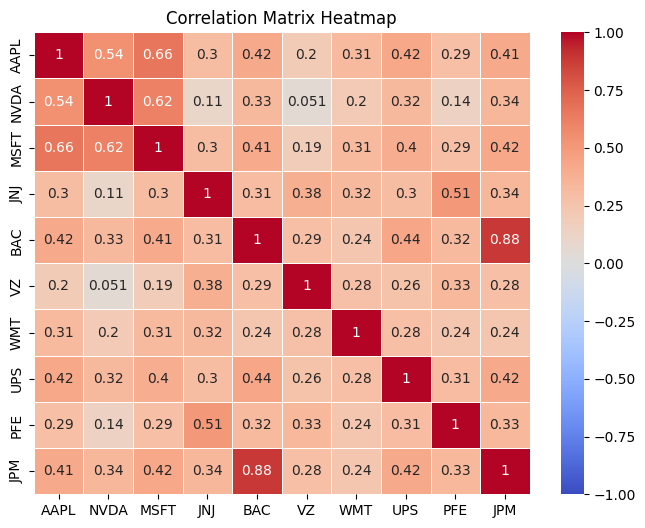

In [11]:
create_correlation_heatmap(corr_matrix)

### Set up an optimal portfolio simulation calculation ###

In [12]:
close_price_df = data_pipe.build_close_price_df(tickers)

close_price_df.head()

,AAPL,NVDA,MSFT,JNJ,BAC,VZ,WMT,UPS,PFE,JPM
Date,,,,,,,,,,
2016-02-25,21.914253,0.777879,45.842205,80.801292,9.895345,30.181002,18.902971,67.387550,18.732599,43.594315
2016-02-26,21.948217,0.772757,45.138306,80.345589,10.200561,30.127855,18.477903,67.194511,18.512146,43.999596
2016-02-29,21.898396,0.767738,44.768764,79.912613,10.055986,29.956606,18.430674,66.580734,18.169218,43.051395
2016-03-01,22.768084,0.801767,46.264561,81.439331,10.594126,30.387678,18.464016,67.828918,18.395792,45.268955
2016-03-02,22.817911,0.806419,46.590130,81.302635,10.811815,30.777422,18.394558,68.111633,18.359055,45.697170


In [13]:
sim_runs = 100
initial_investment = 1000000
n = len(close_price_df.columns)
print(n)

# I will set up placeholders to store all outputs of the simulation calculation:
weights_runs = np.zeros((sim_runs, n))
sharpe_ratio_runs = np.zeros(sim_runs)
expected_portfolio_returns_runs = np.zeros(sim_runs)
volatility_runs = np.zeros(sim_runs)
return_on_investment_runs = np.zeros(sim_runs)
final_value_runs = np.zeros(sim_runs)


10


## Run the calculations to obtain an efficient frontier and the optimal portfolio ##

In [14]:
for i in range(sim_runs):
    # Generate random weights
    weights = p_sim.generate_portfolio_weights(n)
    # Store the weights
    weights_runs[i, :] = weights

    # Call "simulation_engine" function and store Sharpe ratio, return and volatility
    # Note that asset allocation is performed using the "asset_allocation" function
    expected_portfolio_returns_runs[i], volatility_runs[i], sharpe_ratio_runs[i], final_value_runs[i], \
    return_on_investment_runs[i] = p_sim.simulation_engine(close_price_df, weights, initial_investment)

    if i % 250 == 0:
        print(f"Simulation Run = {i}")
        print(f"Weights = {weights_runs[i].round(3)}, Final Value = ${final_value_runs[i]:.2f}, Sharpe Ratio = {sharpe_ratio_runs[i]:.5f}")
        print('\n')

Simulation Run = 0
Weights = [0.181 0.255 0.015 0.022 0.009 0.074 0.164 0.154 0.044 0.082], Final Value = $49171721.08, Sharpe Ratio = 1.27886




### In this step, we extract the output data produced in the simulation calculation ###

- There is a problem - what if Sharpe Ratio is a negative?! #TODO

In [15]:
sim_out_df = pd.DataFrame({'Volatility': volatility_runs.tolist(), 
                           'Portfolio_Return': expected_portfolio_returns_runs.tolist(), 
                           'Sharpe_Ratio': sharpe_ratio_runs.tolist() })
print(sim_out_df)

max_sharpe_idx = sim_out_df["Sharpe_Ratio"].idxmax()
optimal_portfolio = sim_out_df.loc[max_sharpe_idx]
cloud_df = sim_out_df.drop(index=max_sharpe_idx)
optimal_portfolio_weights = weights_runs[max_sharpe_idx]

print(optimal_portfolio)

    Volatility  Portfolio_Return  Sharpe_Ratio
0     0.219223          0.310357      1.278862
1     0.188200          0.256159      1.201694
2     0.197492          0.267455      1.202357
3     0.180630          0.229987      1.107164
4     0.172450          0.233212      1.178380
..         ...               ...           ...
95    0.193910          0.248769      1.128198
96    0.182514          0.196103      0.910081
97    0.181467          0.223875      1.068379
98    0.182706          0.237362      1.134949
99    0.166731          0.210321      1.081509

[100 rows x 3 columns]
Volatility          0.205844
Portfolio_Return    0.296911
Sharpe_Ratio        1.296666
Name: 24, dtype: float64


### We will now plot the results and make some interesting observations ###

In [16]:
fig = px.scatter(
    cloud_df,
    x="Volatility",
    y="Portfolio_Return",
    color="Sharpe_Ratio",
    size="Sharpe_Ratio",
    opacity=0.5,
    hover_data=["Sharpe_Ratio"]
)

fig.add_trace(go.Scatter(
    x=[optimal_portfolio["Volatility"]],
    y=[optimal_portfolio["Portfolio_Return"]],
    mode="markers+text",
    marker=dict(color="red", size=25, line=dict(color="orange", width=2)),
    name="Optimal Portfolio",
    text=["Optimal"],
    textposition="top left"
))

fig.update_layout(plot_bgcolor="white")
fig.show()

# Plot interactive plot for volatility
fig = px.line(sim_out_df, y = 'Volatility')
fig.show()

# Plot interactive plot for Portfolio Return
fig = px.line(sim_out_df, y = 'Portfolio_Return')
fig.update_traces(line_color = 'red')
fig.show()

# Plot interactive plot for Portfolio Return
fig = px.line(sim_out_df, y = 'Sharpe_Ratio')
fig.update_traces(line_color = 'purple')
fig.show()

### Finally, let's print and take not of the optimal portfolio weights ###

In [17]:
print(list(zip(tickers, optimal_portfolio_weights)))

[('AAPL', np.float64(0.07644849184981763)), ('NVDA', np.float64(0.18721430463398256)), ('MSFT', np.float64(0.2202356247143922)), ('JNJ', np.float64(0.12487639362396351)), ('BAC', np.float64(0.10659871534606365)), ('VZ', np.float64(0.005584380889401436)), ('WMT', np.float64(0.22467360700831338)), ('UPS', np.float64(0.04720614145459715)), ('PFE', np.float64(0.00558441554737216)), ('JPM', np.float64(0.0015779249320962696))]


### Conclusion ###

So far we have used very little math. Most of us in the finance profession are taught to understand intuitively the concept and find practical solutions, without fully understanding the linear algebra and the geometry behind it. I substituted the actual solution produced by Markowitz in 1952, where he optimized to find the portfolio weights of a portfolio including predefined risk-bearing assets by finding the lowest-variance portfolio for each targeted level for portfolio return.

Instead of solving, I just produced n different portfolios by randomly generating weights, calculted their variance and returns and then plotted each return-variance combination on a scatter plot. The bright yellow dots appear to form a parabolic shape, which actually defines the efficient frontier defined by Markowitz. The greater n is in term of simulation runs, the closer the result is to the actual outcome. I will leave the variable sim_runs at 10 000, but you can try even higher. For example I tried 30 000 runs, it took around 20 minutes to calculate. But this is brute force, not mathematics. 

Let's now move to notebook 1_2 in order to observe how the theory and its supporting mathematics actually work. 